# Text Classification using Pretrained BERT
### E-commerce Product Description Classification

**Dataset:** [E-commerce Text Classification](https://www.kaggle.com/datasets/saurabhshahane/ecommerce-text-classification) (Kaggle)







## 1. Install & Import Required Libraries




In [ ]:


!pip install -q kagglehub keras-hub tensorflow scikit-learn pandas matplotlib seaborn



In [ ]:
# ---- Set the Keras 3 backend to TensorFlow BEFORE importing keras / keras_hub ----
# (Keras 3 supports multiple backends: tensorflow, jax, torch. This assignment requires
#  TensorFlow/Keras only, so we pin the backend explicitly.)
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

# ---- Core libraries ----
import re
import glob
import numpy as np
import pandas as pd

# ---- Visualization ----
import matplotlib.pyplot as plt
import seaborn as sns

# ---- Scikit-learn utilities ----
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# ---- TensorFlow / Keras (deep learning framework used in this notebook) ----
import tensorflow as tf
import keras

# ---- KerasHub: provides the pretrained BERT model + built-in tokenizer/preprocessor ----
import keras_hub

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
keras.utils.set_random_seed(SEED)

print('Keras backend in use:', keras.backend.backend())
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))


Keras backend in use: tensorflow
TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Download the Dataset using `kagglehub`




In [ ]:
import kagglehub

# Download latest version of the dataset from Kaggle
path = kagglehub.dataset_download("saurabhshahane/ecommerce-text-classification")

print("Path to dataset files:", path)

# List all files inside the downloaded dataset folder
for f in os.listdir(path):
    print(" -", f)


Using Colab cache for faster access to the 'ecommerce-text-classification' dataset.
Path to dataset files: /kaggle/input/ecommerce-text-classification
 - ecommerceDataset.csv


## 3. Load & Explore the Dataset



In [ ]:
# Automatically find the main CSV file inside the downloaded dataset folder
csv_files = glob.glob(os.path.join(path, "**", "*.csv"), recursive=True)
print("CSV files found:", csv_files)

# Pick the file that looks like the main dataset
csv_path = max(csv_files, key=os.path.getsize)
print("\nUsing file:", csv_path)

# The original file has no header, so we assign column names manually:
# column 1 -> product category (label), column 2 -> product description (text)
df = pd.read_csv(csv_path, header=None, names=["category", "text"])

print("Dataset shape:", df.shape)
df.head()


CSV files found: ['/kaggle/input/ecommerce-text-classification/ecommerceDataset.csv']

Using file: /kaggle/input/ecommerce-text-classification/ecommerceDataset.csv
Dataset shape: (50425, 2)


,category,text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ..."
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1..."
4,Household,Incredible Gifts India Wooden Happy Birthday U...


Categories: ['Household' 'Books' 'Clothing & Accessories' 'Electronics']

Number of classes: 4


/tmp/ipykernel_1592/747086805.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="category", data=df, order=df['category'].value_counts().index, palette="viridis")


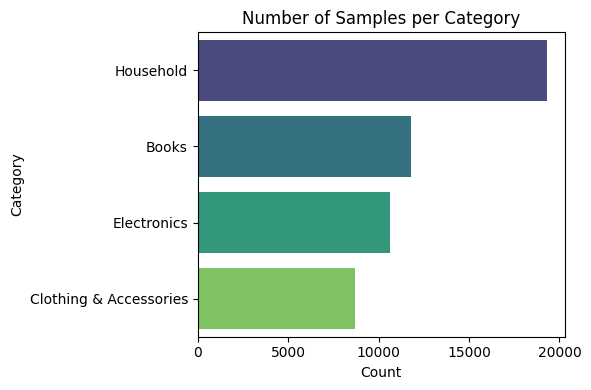

In [ ]:
# Drop rows with missing values (if any)
df = df.dropna(subset=["category", "text"]).reset_index(drop=True)

# Check the unique categories (our target classes)
print("Categories:", df['category'].unique())
print("\nNumber of classes:", df['category'].nunique())

# Visualize class distribution
plt.figure(figsize=(6, 4))
sns.countplot(y="category", data=df, order=df['category'].value_counts().index, palette="viridis")
plt.title("Number of Samples per Category")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()


## 4. Clean & Preprocess Text
We apply light text cleaning (lowercasing, removing extra whitespace/special characters).

In [ ]:
def clean_text(text):
    """Basic text cleaning: lowercase, remove extra spaces and non-alphanumeric noise."""
    text = str(text).lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)   # remove special characters
    text = re.sub(r"\s+", " ", text).strip()    # collapse multiple spaces
    return text

df["clean_text"] = df["text"].apply(clean_text)

# Remove any rows that became empty after cleaning
df = df[df["clean_text"].str.len() > 0].reset_index(drop=True)

df[["category", "text", "clean_text"]].head()


,category,text,clean_text
0,Household,Paper Plane Design Framed Wall Hanging Motivat...,paper plane design framed wall hanging motivat...
1,Household,"SAF 'Floral' Framed Painting (Wood, 30 inch x ...",saf floral framed painting wood 30 inch x 10 i...
2,Household,SAF 'UV Textured Modern Art Print Framed' Pain...,saf uv textured modern art print framed painti...
3,Household,"SAF Flower Print Framed Painting (Synthetic, 1...",saf flower print framed painting synthetic 13 ...
4,Household,Incredible Gifts India Wooden Happy Birthday U...,incredible gifts india wooden happy birthday u...


## 5. Encode Labels & Train/Test Split
We convert the text category labels into integers using `LabelEncoder`.

In [ ]:
# ---- Encode text labels into numbers (e.g. 'Electronics' -> 0, 'Books' -> 1, ...) ----
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["category"])
num_classes = df["label"].nunique()

print("Classes:", list(label_encoder.classes_))
print("Number of classes:", num_classes)

# ---- Optional: subsample the dataset to keep training time reasonable ----
SAMPLE_SIZE = 6000   # set to None to use the FULL dataset (will take much longer to train)

if SAMPLE_SIZE is not None and SAMPLE_SIZE < len(df):
    df_sample = df.groupby("label", group_keys=False).apply(
        lambda x: x.sample(int(SAMPLE_SIZE / num_classes), random_state=SEED, replace=False)
    ).reset_index(drop=True)
else:
    df_sample = df.copy()

print("\nWorking dataset size:", df_sample.shape)

# ---- Train / Validation / Test split (70% / 15% / 15%) ----
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df_sample["clean_text"].tolist(),
    df_sample["label"].tolist(),
    test_size=0.30,
    random_state=SEED,
    stratify=df_sample["label"],
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels,
)

train_labels = np.array(train_labels)
val_labels = np.array(val_labels)
test_labels = np.array(test_labels)

print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))
print("Test size:", len(test_texts))


Classes: ['Books', 'Clothing & Accessories', 'Electronics', 'Household']
Number of classes: 4

Working dataset size: (6000, 4)
Train size: 4200
Validation size: 900
Test size: 900


/tmp/ipykernel_1592/2145870854.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby("label", group_keys=False).apply(


## 6. Build the BERT Classification Model (KerasHub, TensorFlow)




In [ ]:

PRESET = "bert_base_en_uncased"   # pretrained BERT checkpoint (uncased, base size)
MAX_LEN = 128                      # max number of tokens per product description

# Load a pretrained BERT classifier: backbone + tokenizer/preprocessor + classification head,
# all bundled together as one Keras Model.
classifier = keras_hub.models.BertTextClassifier.from_preset(
    PRESET,
    num_classes=num_classes,
    activation="softmax",             # output class probabilities directly
    preprocessor=keras_hub.models.BertTextClassifierPreprocessor.from_preset(
        PRESET, sequence_length=MAX_LEN
    ),
)

classifier.summary()


100%|██████████| 457/457 [00:00<00:00, 787kB/s]


100%|██████████| 761/761 [00:00<00:00, 1.24MB/s]


100%|██████████| 226k/226k [00:00<00:00, 1.10MB/s]


Preprocessor: "bert_text_classifier_preprocessor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                                                  ┃                                   Config ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ bert_tokenizer (BertTokenizer)                                │                       Vocab size: 30,522 │
└───────────────────────────────────────────────────────────────┴──────────────────────────────────────────┘

Model: "bert_text_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ padding_mask (InputLayer)     │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ segment_ids (InputLayer)      │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ token_ids (InputLayer)        │ (None, None)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bert_backbone (BertBackbone)  │ [(None, 768), (None,      │     109,482,240 │ padding_mask[0][0],        │
│                               │ None, 768)]               │                 │ segment_ids[0][0],         │
│                               │                           │                 │ token_ids[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ classifier_dropout (Dropout)  │ (None, 768)               │               0 │ bert_backbone[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ logits (Dense)                │ (None, 4)                 │           3,076 │ classifier_dropout[0][0]   │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 109,485,316 (417.65 MB)

 Trainable params: 109,485,316 (417.65 MB)

 Non-trainable params: 0 (0.00 B)

## 7. Compile & Train the Model



In [ ]:
# Fine-tuning BERT requires a very small learning rate
classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=2e-5),
    loss=keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"],
)

early_stop = keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)

EPOCHS = 3       # small number of epochs is usually enough when fine-tuning BERT
BATCH_SIZE = 16

# Raw text strings can be passed directly as `x` -- the built-in preprocessor tokenizes them on the fly.
history = classifier.fit(
    x=train_texts,
    y=train_labels,
    validation_data=(val_texts, val_labels),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
)


Epoch 1/3
263/263 ━━━━━━━━━━━━━━━━━━━━ 204s 529ms/step - accuracy: 0.8879 - loss: 0.4066 - val_accuracy: 0.9422 - val_loss: 0.2082
Epoch 2/3
263/263 ━━━━━━━━━━━━━━━━━━━━ 107s 405ms/step - accuracy: 0.9569 - loss: 0.1736 - val_accuracy: 0.9511 - val_loss: 0.1896
Epoch 3/3
263/263 ━━━━━━━━━━━━━━━━━━━━ 107s 405ms/step - accuracy: 0.9760 - loss: 0.1038 - val_accuracy: 0.9511 - val_loss: 0.1809


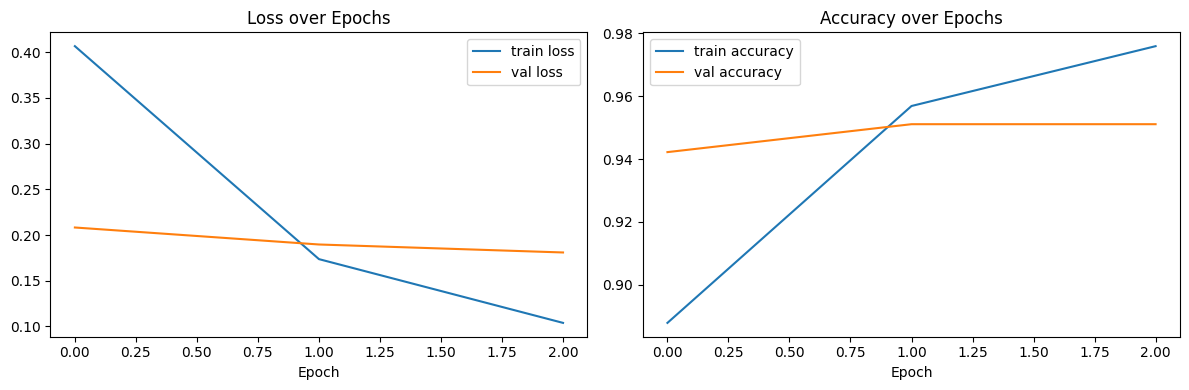

In [ ]:
# ---- Plot training history ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history["loss"], label="train loss")
axes[0].plot(history.history["val_loss"], label="val loss")
axes[0].set_title("Loss over Epochs")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="train accuracy")
axes[1].plot(history.history["val_accuracy"], label="val accuracy")
axes[1].set_title("Accuracy over Epochs")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


## 8. Evaluate the Model on the Test Set


In [ ]:
# Evaluate overall loss & accuracy on the held-out test set
test_loss, test_accuracy = classifier.evaluate(x=test_texts, y=test_labels, batch_size=BATCH_SIZE)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


57/57 ━━━━━━━━━━━━━━━━━━━━ 7s 121ms/step - accuracy: 0.9567 - loss: 0.1795

Test Loss: 0.1795
Test Accuracy: 0.9567


57/57 ━━━━━━━━━━━━━━━━━━━━ 14s 187ms/step
Classification Report:

                        precision    recall  f1-score   support

                 Books       0.94      0.96      0.95       225
Clothing & Accessories       0.97      1.00      0.98       225
           Electronics       0.98      0.93      0.95       225
             Household       0.94      0.94      0.94       225

              accuracy                           0.96       900
             macro avg       0.96      0.96      0.96       900
          weighted avg       0.96      0.96      0.96       900



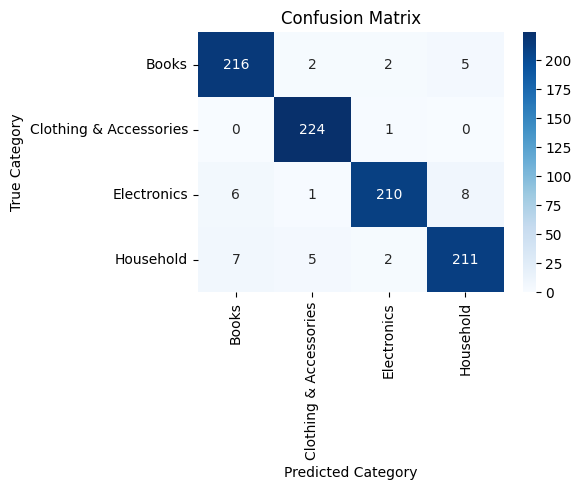

In [ ]:
# ---- Detailed classification report & confusion matrix ----
y_pred_probs = classifier.predict(x=test_texts, batch_size=BATCH_SIZE)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.array(test_labels)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Confusion matrix heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted Category")
plt.ylabel("True Category")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


## 9. Test the Model on Custom Sample Text


In [ ]:
def predict_category(text, classifier=classifier, label_encoder=label_encoder):
    """Cleans the text and predicts the category using the fine-tuned classifier."""
    cleaned = clean_text(text)
    probs = classifier.predict(x=[cleaned], batch_size=1, verbose=0)[0]
    pred_label = np.argmax(probs)
    pred_category = label_encoder.inverse_transform([pred_label])[0]
    confidence = probs[pred_label]
    return pred_category, confidence

# Try a few sample product descriptions
sample_texts = [
    "Samsung 32 inch smart LED TV with HDR support and built-in WiFi",
    "Cotton casual t-shirt for men, slim fit, available in multiple colors",
    "The Alchemist a novel by Paulo Coelho, paperback edition",
    "Stainless steel kitchen knife set with wooden storage block",
]

for text in sample_texts:
    category, confidence = predict_category(text)
    print(f"Text: {text}")
    print(f"  -> Predicted Category: {category}  (confidence: {confidence:.2f})\n")


Text: Samsung 32 inch smart LED TV with HDR support and built-in WiFi
  -> Predicted Category: Electronics  (confidence: 0.82)

Text: Cotton casual t-shirt for men, slim fit, available in multiple colors
  -> Predicted Category: Clothing & Accessories  (confidence: 1.00)

Text: The Alchemist a novel by Paulo Coelho, paperback edition
  -> Predicted Category: Books  (confidence: 0.99)

Text: Stainless steel kitchen knife set with wooden storage block
  -> Predicted Category: Household  (confidence: 0.99)

